# Testing Robustness to Change in Speckle Field

If we need to re-calibrate iEFC every single time we want to do it, we will be spending hours doing WFSC. In this notebook, I hope to explore if we could calibrate the iEFC controller during daytime (or at the beginning of observations) and keep using it subject to changing WFE.

In [1]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling, unfocus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

## Configure the deformable mirror model

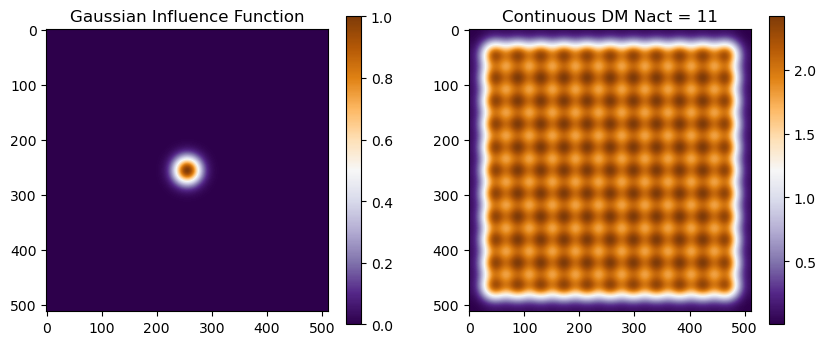

In [2]:
# First we need a forward model of the system
# NOTE: Influence functions should peak at 1

# Basic inputs to a prysm DM
# - influence function
# - number of actuators in X and Y axes
# - separation of the actuators in the array containing the lattice, in units of samples

nact = 11
act_pitch = 6
samples_per_act = 42
sampling_pitch = act_pitch / samples_per_act

x, y = make_xy_grid(512, dx=sampling_pitch)
r, th = cart_to_polar(x, y)
influence_func = gaussian_influence_function(r, act_pitch)#np.sinc(x/act_pitch) * np.sinc(y/act_pitch)
# influence_func /= np.max(influence_func)
Nout = x.shape[0]
dm = DM(influence_func, Nout, nact, samples_per_act, rot=(0,0,0), shift=(samples_per_act, samples_per_act))

dm.actuators[:] = 1

plt.figure(figsize=[10, 4])
plt.subplot(121)
plt.title("Gaussian Influence Function")
plt.imshow(influence_func, cmap="PuOr_r")
plt.colorbar()
plt.subplot(122)
plt.title(f"Continuous DM Nact = {nact}")
plt.imshow(dm.render(), cmap="PuOr_r")
plt.colorbar()
plt.show()
dm.actuators[:] = 0

## Configure WFE model
Using a PSD to generate several realizations of WFE with the same statistics

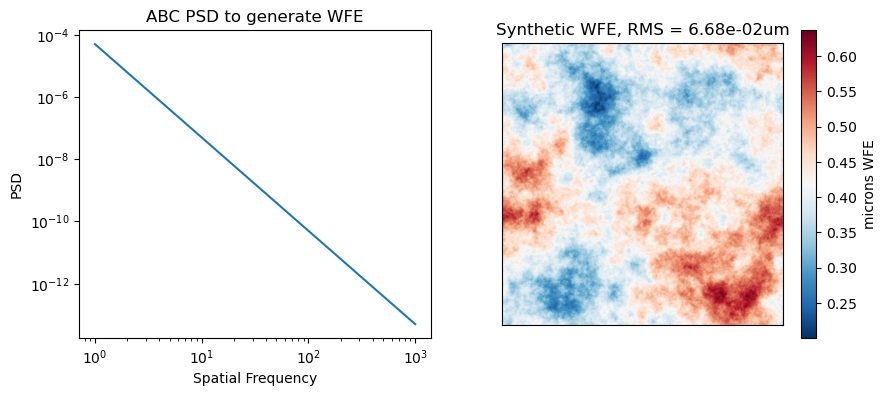

In [3]:
# set up PSD
A = 5e4
B = 1/1000
C = 3
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=A, b=B, c=C)

# Just picked ABC values until it looked about right
Npup = Nout
WFE_REALIZATIONS = 10
wfe_maps = []
for i in range(WFE_REALIZATIONS):

    _, _, z = render_synthetic_surface(10, Npup, a=A, b=B, c=C)
    wfe_maps.append(z)

plt.figure(figsize=[10, 4])
plt.subplot(121)
plt.title("ABC PSD to generate WFE")
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')

plt.subplot(122)
plt.title(f'Synthetic WFE, RMS = {np.std(z):.2e}um')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

## Configure Diffraction Model

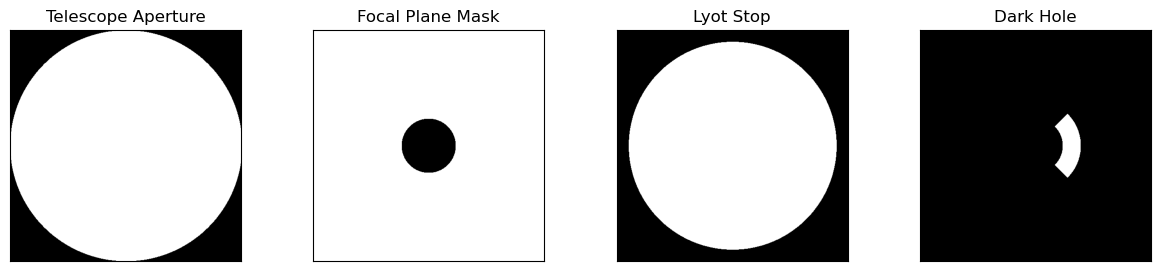

In [4]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)

# Entrance pupil, lyot stop
A = circle(1, r)
LS = circle(0.9, r)

# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1/2 # microns
Nimg = Npup

# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
u, v = make_xy_grid(Nimg, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

# Focal plane mask and dark hole
dark_hole = np.zeros_like(u)
IWA = 3
OWA = 5
CORO_IWA = 3
dark_hole[rho < OWA] = 1
dark_hole[rho < IWA] = 0
dark_hole[psi < -np.pi / 4] = 0
dark_hole[psi > np.pi / 4] = 0

FPM = np.ones_like(u)
FPM[ rho < CORO_IWA] = 0

plt.figure(figsize=[15,3])
plt.subplot(141)
plt.imshow(A, cmap='gray')
plt.xticks([],[])
plt.yticks([],[])
plt.title('Telescope Aperture')
plt.subplot(142)
plt.imshow(FPM, cmap='gray')
plt.title('Focal Plane Mask')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(143)
plt.imshow(LS, cmap='gray')
plt.title('Lyot Stop')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(144)
plt.imshow(dark_hole, cmap='gray')
plt.title('Dark Hole')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

In [5]:
def snap_image(pupil_wfe=np.ones_like(A), include_fpm=True, nominal_wfe=wfe_maps[0]):
    """take intensity image given a pupil wfe in microns

    Parameters
    ----------
    pupil_wfe : ndarray, optional
        wavefront error in microns, by default np.ones_like(A)
    """

    # create nominal wavefront
    wfe = np.exp(1j * 2 * np.pi / WVL * (pupil_wfe + nominal_wfe)) * A
    wvfnt_to_prop = wfe

    # propagate to focus
    focal = focus_fixed_sampling(wvfnt_to_prop,
                                input_dx=Dpup / wfe.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=Nimg)
    
    if include_fpm:
        focal *= FPM

    lyot = unfocus_fixed_sampling(focal,
                                input_dx=dx_img, # um
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=Dpup / wfe.shape[0], # mm
                                output_samples=wfe.shape[0])
    
    lyot *= LS

    coro = focus_fixed_sampling(lyot,
                                input_dx=Dpup / wfe.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=Nimg)
    
    return np.abs(coro)**2


# Calibrate to state of first simulated WFE

Note that in forward model we calibrate to the state of a given WFE

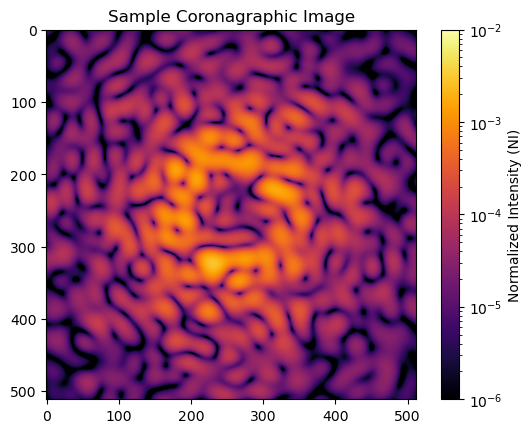

In [6]:
ref_contrast = snap_image(include_fpm=False).max()

plt.figure()
plt.title("Sample Coronagraphic Image")
plt.imshow(snap_image() / ref_contrast, cmap='inferno', norm=LogNorm(vmin=1e-6, vmax=1e-2))
plt.colorbar(label="Normalized Intensity (NI)")
plt.show()

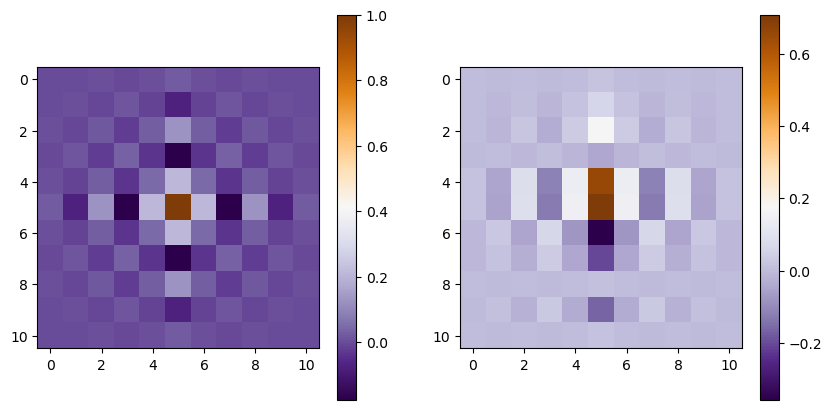

In [7]:
from poi.modes import poke_mode_sequence
from poi.probes import create_sinc_probe, create_fourier_probes

xact, yact = make_xy_grid(nact, dx=act_pitch)
rhoact, thact = cart_to_polar(xact, yact)
circ_dm_mask = np.ones_like(xact)

modes = poke_mode_sequence(circ_dm_mask)


amp = 1
probe_radius = 4.5 # is this L/D ?
shift = (0, 0)

dm_mask = np.ones([nact, nact])

probe1 = create_sinc_probe(Nacts=nact,
                          amp=amp,
                          probe_radius=probe_radius)

probe2 = create_sinc_probe(Nacts=nact,
                          amp=amp,
                          probe_radius=probe_radius,
                          offset=shift,
                          probe_phase=np.pi / 4)

# probe1, probe2 = create_fourier_probes(dm_mask, 256, dx_img * um_to_LD, iwa=IWA, owa=OWA)

# probe1 = np.zeros_like(probe1)
# probe1[5,5] = 1
# probe2 = np.zeros_like(probe2)
# probe2[5,7] = 1


plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(probe1, cmap="PuOr_r")
plt.colorbar()
plt.subplot(122)
plt.imshow(probe2, cmap="PuOr_r")
plt.colorbar()
plt.show()

In [8]:
from poi.efc import iEFC

iefc = iEFC(snap_image, dm, modes, [probe1, probe2], dark_hole,
            probe_amplitude=20e-3, # radians, change to 20nm
            mode_amplitude=20e-3,
            ref_contrast=ref_contrast)

In [9]:
# calibrate current state
iefc.calibrate()
iefc.compute_control_matrix(beta=-2.5)

121it [02:30,  1.25s/it]


## Take starter image

In [10]:
from poi.processing import azimuthal_average

profiles = []
img = snap_image(dm.render(wfe=True)) / ref_contrast
# img = iefc.step()
pro, bins = azimuthal_average(img)
profiles.append(pro)

## Change the forward model to a different wfe realization

In [11]:
def snap_image_wfe1(pupil_wfe=np.ones_like(A), include_fpm=True, nominal_wfe=wfe_maps[1]):
    """take intensity image given a pupil wfe in microns

    Parameters
    ----------
    pupil_wfe : ndarray, optional
        wavefront error in microns, by default np.ones_like(A)
    """

    # create nominal wavefront
    wfe = np.exp(1j * 2 * np.pi / WVL * (pupil_wfe + nominal_wfe)) * A
    wvfnt_to_prop = wfe

    # propagate to focus
    focal = focus_fixed_sampling(wvfnt_to_prop,
                                input_dx=Dpup / wfe.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=Nimg)
    
    if include_fpm:
        focal *= FPM

    lyot = unfocus_fixed_sampling(focal,
                                input_dx=dx_img, # um
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=Dpup / wfe.shape[0], # mm
                                output_samples=wfe.shape[0])
    
    lyot *= LS

    coro = focus_fixed_sampling(lyot,
                                input_dx=Dpup / wfe.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=Nimg)
    
    return np.abs(coro)**2

iefc.fwd = snap_image_wfe1

## Advance algorithm 1 realization without recalibration

In [29]:
img_wfe1 = iefc.step(loop_gain=1.)
pro, bins = azimuthal_average(img_wfe1)
profiles.append(pro)

## Plot the dark zones

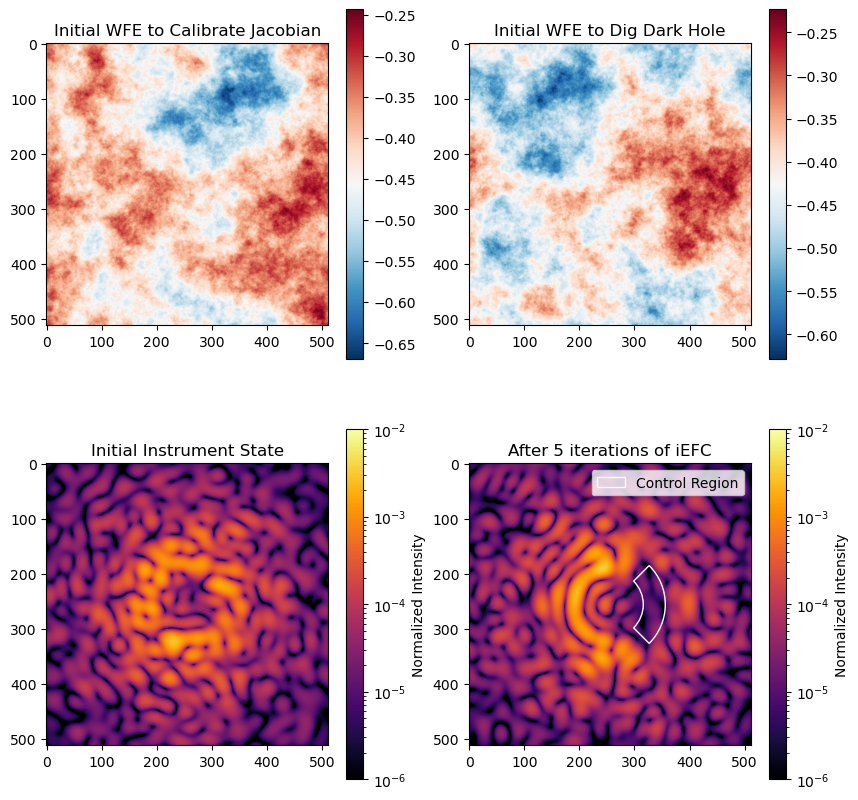

In [43]:
from matplotlib.patches import Wedge
plt.style.use("default")
plt.figure(figsize=[10, 10])

plt.subplot(221)
plt.title("Initial WFE to Calibrate Jacobian")
plt.imshow(wfe_maps[0], cmap="RdBu_r")
plt.colorbar()

plt.subplot(222)
plt.title("Initial WFE to Dig Dark Hole")
plt.imshow(wfe_maps[1], cmap="RdBu_r")
plt.colorbar()

plt.subplot(223)
plt.title("Initial Instrument State")
plt.imshow(img, cmap="inferno", norm=LogNorm(vmin=1e-6, vmax=1e-2))
plt.colorbar(label="Normalized Intensity")

plt.subplot(224)
plt.title("After 5 iterations of iEFC")
plt.imshow(img_wfe1, cmap="inferno", norm=LogNorm(vmin=1e-6, vmax=1e-2))
plt.colorbar(label="Normalized Intensity")

ax = plt.gca()
dh_region = Wedge([256, 256], theta1=-45, theta2=45, r=OWA / (dx_img * um_to_LD), width=(OWA - IWA) / (dx_img * um_to_LD),
                  facecolor="None", edgecolor="w", label="Control Region")
ax.add_patch(dh_region)
plt.legend()
plt.show()

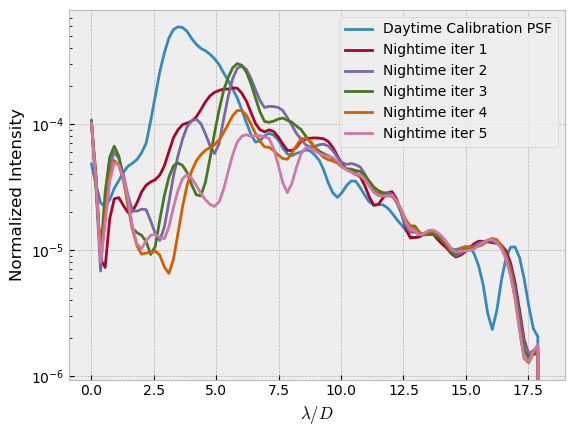

In [38]:
plt.style.use("bmh")
plt.plot(bins * dx_img * um_to_LD, np.asarray(profiles[:-1]).T,
                                       label=["Daytime Calibration PSF",
                                              "Nightime iter 1",
                                              "Nightime iter 2",
                                              "Nightime iter 3",
                                              "Nightime iter 4",
                                              "Nightime iter 5",])
plt.yscale("log")
plt.legend()
plt.ylabel("Normalized Intensity")
plt.xlabel(r"$\lambda / D$")
plt.show()

A SR > 1 indicates the wavefront quality got better


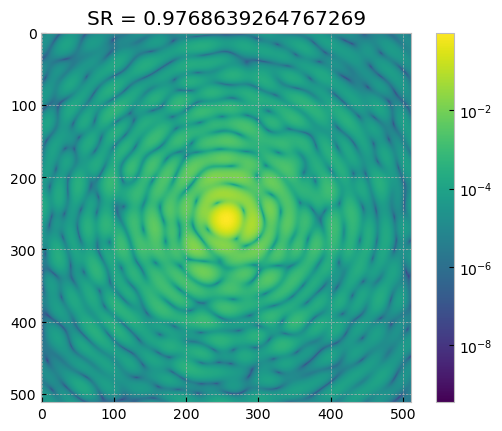

In [15]:
img_check = snap_image(dm.render(wfe=True), include_fpm=False)

print("A SR > 1 indicates the wavefront quality got better")
plt.title(f"SR = {img_check.max() / ref_contrast}")
plt.imshow(img_check / ref_contrast, norm=LogNorm())
plt.colorbar()